# Sprint 8 - Proyecto

## Paso 4. Análisis exploratorio de datos

En esta sección se analizarán dos conjuntos de datos:

- `project_sql_result_01.csv`: información sobre las compañías de taxi y el número de viajes realizados.
- `project_sql_result_04.csv`: información sobre los barrios de destino y el promedio de viajes finalizados.

El objetivo es revisar la calidad de los datos, validar los tipos de datos, identificar los principales barrios de destino y visualizar los resultados.

### 4.1 Importación de datos

Se cargan los archivos CSV necesarios para el análisis y las librerías que se utilizarán durante el proyecto.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

companies = pd.read_csv('data/moved_project_sql_result_01.csv')
neighborhoods = pd.read_csv('data/moved_project_sql_result_04.csv')
rides_weather = pd.read_csv('data/moved_project_sql_result_07.csv')

### 4.2 Revisión del dataset de compañías de taxi

Primero se revisará la estructura del dataset, los tipos de datos, la presencia de valores ausentes y posibles filas duplicadas.

In [35]:
display(companies.head())

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [36]:
companies.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


In [37]:
display(companies.describe())

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


In [38]:
print('Valores ausentes:')
print(companies.isna().sum())

print('\nFilas duplicadas:', companies.duplicated().sum())

Valores ausentes:
company_name    0
trips_amount    0
dtype: int64

Filas duplicadas: 0


#### Conclusión sobre la calidad de los datos

El dataset contiene 64 compañías de taxi y no presenta valores ausentes ni filas duplicadas.

Los tipos de datos son adecuados:

- `company_name` es de tipo texto.
- `trips_amount` es de tipo entero.

También se observa una diferencia considerable entre la media y la mediana del número de viajes. Esto sugiere que la distribución está sesgada y que unas pocas compañías concentran una proporción importante de los viajes.

### 4.3 Revisión del dataset de barrios

A continuación se revisará el dataset de barrios de destino para comprobar su estructura, tipos de datos, valores ausentes y duplicados.

In [39]:
display(neighborhoods.head())

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [40]:
neighborhoods.info()

<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     str    
 1   average_trips          94 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.6 KB


In [41]:
display(neighborhoods.describe())

,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


In [42]:
print('Valores ausentes:')
print(neighborhoods.isna().sum())

print('\nFilas duplicadas:', neighborhoods.duplicated().sum())

Valores ausentes:
dropoff_location_name    0
average_trips            0
dtype: int64

Filas duplicadas: 0


#### Conclusión sobre la calidad de los datos

El dataset contiene 94 barrios y no presenta valores ausentes ni filas duplicadas.

Los tipos de datos son adecuados:

- `dropoff_location_name` es de tipo texto.
- `average_trips` es de tipo decimal, lo cual es correcto porque representa un promedio.

La diferencia entre la media, la mediana y el valor máximo muestra que los viajes no se distribuyen de manera uniforme entre los barrios.

### 4.4 Top 10 barrios por promedio de viajes finalizados

Se ordenarán los barrios de mayor a menor según el valor de `average_trips` y se seleccionarán los 10 primeros.

In [43]:
top_10_neighborhoods = (
    neighborhoods
    .sort_values('average_trips', ascending=False)
    .head(10)
)

display(top_10_neighborhoods)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


### 4.5 Visualización de los principales barrios de destino

Se construirá un gráfico de barras con los 10 barrios que presentan el mayor promedio de viajes finalizados.

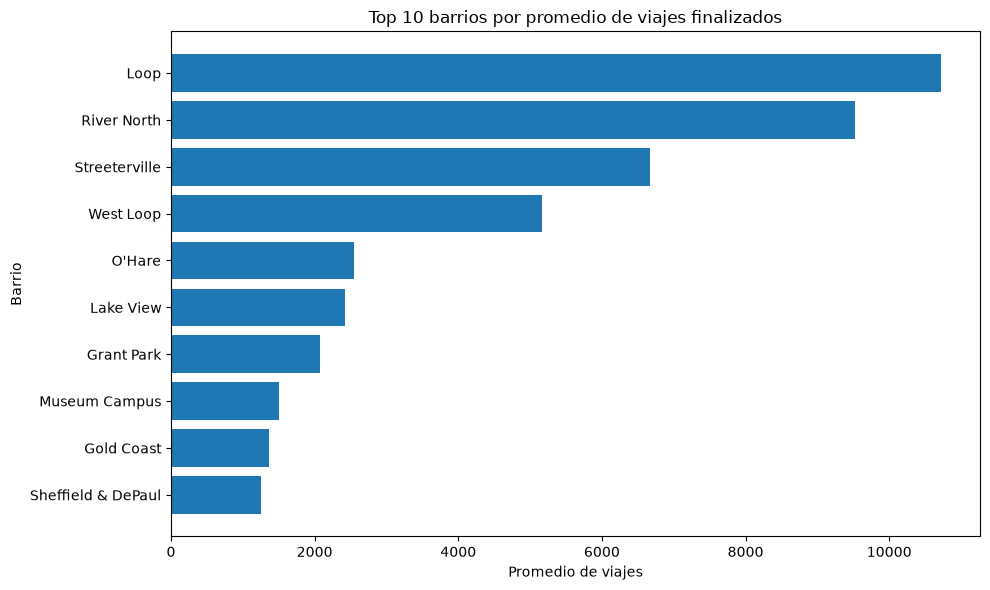

In [44]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_neighborhoods['dropoff_location_name'],
    top_10_neighborhoods['average_trips']
)

plt.xlabel('Promedio de viajes')
plt.ylabel('Barrio')
plt.title('Top 10 barrios por promedio de viajes finalizados')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#### Conclusión

Los barrios con mayor promedio de viajes finalizados son **Loop** y **River North**, seguidos por **Streeterville** y **West Loop**. Se observa una diferencia notable entre los primeros barrios y el resto, lo que indica que los viajes se concentran principalmente en unas pocas zonas de Chicago.

### 4.6 Viajes por compañía de taxi

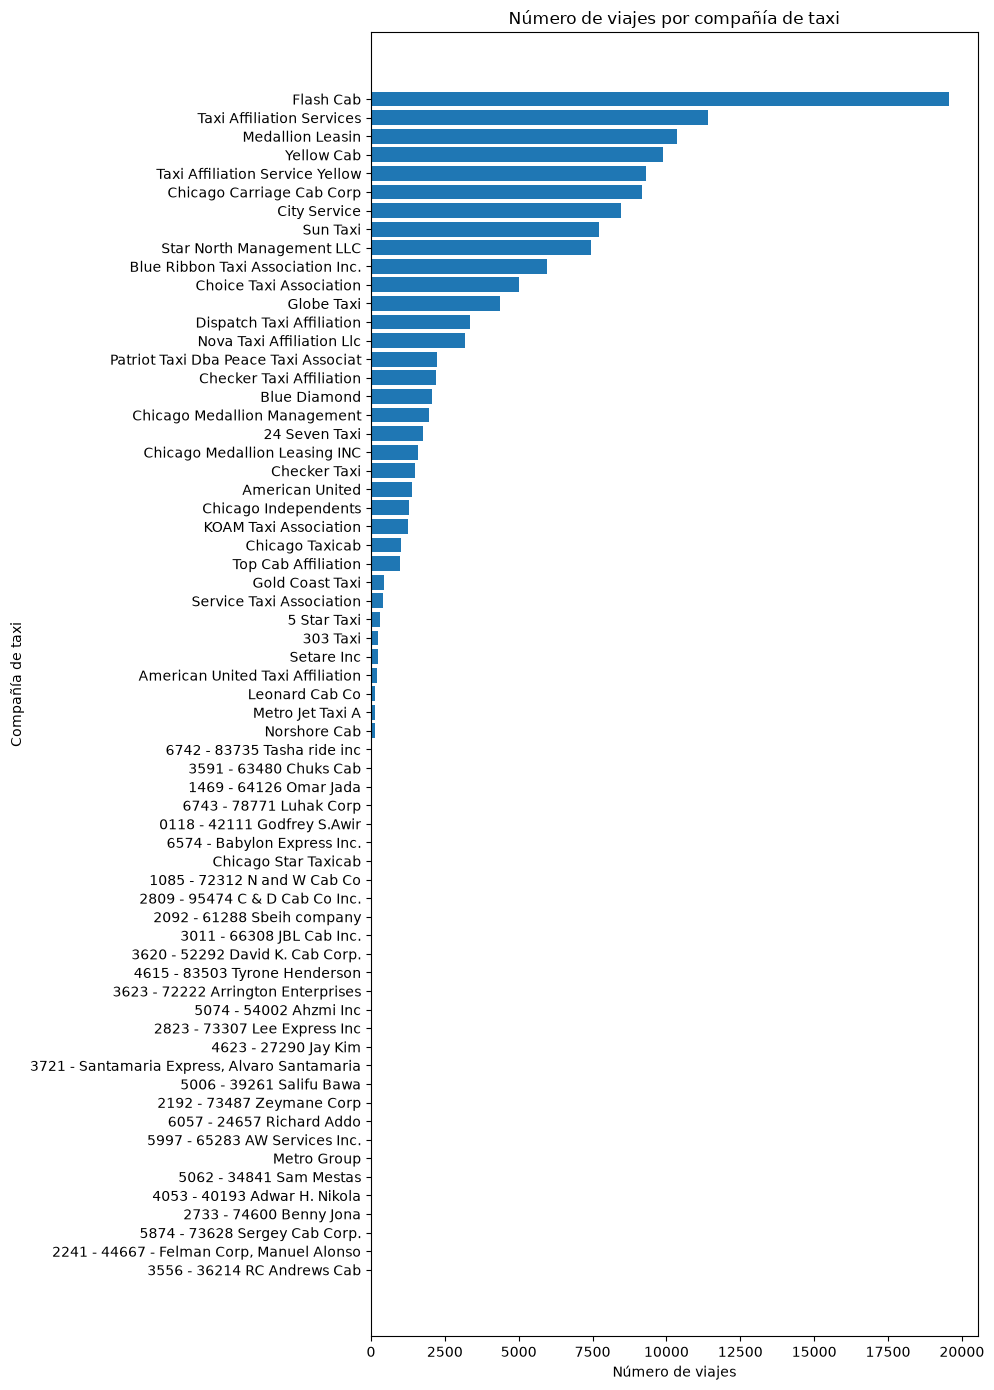

In [45]:
companies_sorted = companies.sort_values(
    by='trips_amount',
    ascending=False
)

plt.figure(figsize=(10, 14))

plt.barh(
    companies_sorted['company_name'],
    companies_sorted['trips_amount']
)

plt.xlabel('Número de viajes')
plt.ylabel('Compañía de taxi')
plt.title('Número de viajes por compañía de taxi')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#### Conclusión

La distribución de viajes entre las compañías de taxi es muy desigual. **Flash Cab** lidera claramente con 19,558 viajes, seguida por **Taxi Affiliation Services** y **Medallion Leasing**. A partir de las primeras compañías, el número de viajes disminuye rápidamente y muchas empresas presentan una actividad muy baja.

Esto indica que una parte importante de los viajes se concentra en un grupo reducido de compañías.

## Paso 5. Prueba de hipótesis

Se analizarán los viajes realizados desde el Loop hasta el Aeropuerto Internacional O'Hare para comprobar si la duración promedio difiere según las condiciones meteorológicas.

In [46]:
display(rides_weather.head())

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [47]:
rides_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   str    
 1   weather_conditions  1068 non-null   str    
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), str(2)
memory usage: 25.2 KB


In [48]:
display(rides_weather.describe())

,duration_seconds
count,1068.000000
mean,2071.731273
std,769.461125
min,0.000000
25%,1438.250000
50%,1980.000000
75%,2580.000000
max,7440.000000


In [49]:
print('Valores ausentes:')
print(rides_weather.isna().sum())

print('\nFilas duplicadas:', rides_weather.duplicated().sum())

Valores ausentes:
start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

Filas duplicadas: 197


In [50]:
rides_weather['start_ts'] = pd.to_datetime(rides_weather['start_ts'])

rides_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[us]
 1   weather_conditions  1068 non-null   str           
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 25.2 KB


In [51]:
print('Condiciones meteorológicas:')
print(rides_weather['weather_conditions'].value_counts())

print('\nViajes con duración igual a 0:')
print((rides_weather['duration_seconds'] == 0).sum())

Condiciones meteorológicas:
weather_conditions
Good    888
Bad     180
Name: count, dtype: int64

Viajes con duración igual a 0:
6


In [52]:
display(
    rides_weather[
        rides_weather['duration_seconds'] == 0
    ]
)

,start_ts,weather_conditions,duration_seconds
163,2017-11-11 09:00:00,Good,0.0
168,2017-11-11 07:00:00,Good,0.0
204,2017-11-18 19:00:00,Good,0.0
552,2017-11-04 01:00:00,Good,0.0
801,2017-11-04 09:00:00,Good,0.0
1063,2017-11-25 11:00:00,Good,0.0


In [53]:
rides_weather = rides_weather[
    rides_weather['duration_seconds'] > 0
].copy()

print('Número de registros después de eliminar duraciones de 0:')
print(len(rides_weather))

Número de registros después de eliminar duraciones de 0:
1062


#### Revisión de los datos

El dataset contenía 1068 registros y no presentaba valores ausentes. La columna `start_ts` se convirtió al tipo `datetime`, ya que representa fecha y hora.

Se encontraron 6 viajes con una duración de 0 segundos. Estos registros se eliminaron porque no representan una duración válida para un viaje entre el Loop y el Aeropuerto Internacional O'Hare.

También se detectaron filas idénticas, pero no se eliminaron, ya que el dataset no incluye `trip_id` y no es posible determinar si corresponden a duplicados reales o a viajes distintos con los mismos valores.

In [54]:
print('Días de la semana presentes en los datos:')
print(rides_weather['start_ts'].dt.dayofweek.value_counts().sort_index())

Días de la semana presentes en los datos:
start_ts
5    1062
Name: count, dtype: int64


La verificación de `start_ts.dt.dayofweek` muestra que los **1062 registros utilizados corresponden al valor 5**, que en pandas representa el sábado. Por lo tanto, todas las observaciones incluidas en la prueba pertenecen al día solicitado.

### Formulación de las hipótesis

**Hipótesis nula (H₀):** la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es igual en condiciones meteorológicas buenas y malas.

**Hipótesis alternativa (H₁):** la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es diferente en condiciones meteorológicas buenas y malas.

Se utilizará un nivel de significación de **α = 0.05**.

In [55]:
good_weather = rides_weather[
    rides_weather['weather_conditions'] == 'Good'
]['duration_seconds']

bad_weather = rides_weather[
    rides_weather['weather_conditions'] == 'Bad'
]['duration_seconds']

print('Viajes con buen clima:', len(good_weather))
print('Viajes con mal clima:', len(bad_weather))

print('\nDuración promedio con buen clima:', good_weather.mean())
print('Duración promedio con mal clima:', bad_weather.mean())

Viajes con buen clima: 882
Viajes con mal clima: 180

Duración promedio con buen clima: 2013.2789115646258
Duración promedio con mal clima: 2427.2055555555557


Se utilizará una prueba t para dos muestras independientes, ya que se comparan las duraciones promedio de dos grupos distintos: viajes con condiciones meteorológicas buenas y malas.

Antes de realizar la prueba t, se comprobará la homogeneidad de las varianzas mediante la prueba de Levene. El resultado de esta prueba determinará si se utiliza `equal_var=True` o `equal_var=False`.

In [56]:
alpha = 0.05

levene_result = stats.levene(good_weather, bad_weather)

print('p-value de la prueba de Levene:', levene_result.pvalue)

equal_var = levene_result.pvalue >= alpha

print('Se utilizará equal_var =', equal_var)

p-value de la prueba de Levene: 0.6687312920630736
Se utilizará equal_var = True


Como el valor p de la prueba de Levene es aproximadamente **0.669**, superior a **0.05**, no hay evidencia suficiente para rechazar la hipótesis de igualdad de varianzas. Por ello, se utiliza `equal_var=True` en la prueba t para dos muestras independientes.

In [57]:
alpha = 0.05

results = stats.ttest_ind(
    good_weather,
    bad_weather,
    equal_var=equal_var
)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula.')
else:
    print('No podemos rechazar la hipótesis nula.')

p-value: 1.3318772977743224e-11
Rechazamos la hipótesis nula.


### Conclusión de la prueba de hipótesis

El valor p obtenido fue aproximadamente **1.33 × 10⁻¹¹**, que es mucho menor que el nivel de significación establecido de **0.05**.

Por lo tanto, se **rechaza la hipótesis nula**.

Existe evidencia estadísticamente significativa de que la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia según las condiciones meteorológicas.

Además, la duración promedio fue mayor en condiciones meteorológicas malas:

- Buen clima: aproximadamente **2013 segundos**
- Mal clima: aproximadamente **2427 segundos**

Esto representa una diferencia de alrededor de **414 segundos**, es decir, aproximadamente **6.9 minutos más** en condiciones meteorológicas malas.

## Conclusión general

El análisis mostró que la actividad de los taxis en Chicago está concentrada tanto en determinadas compañías como en ciertos barrios.

Entre las compañías, **Flash Cab** registró el mayor número de viajes, seguida por **Taxi Affiliation Services** y **Medallion Leasing**. En cuanto a los destinos, **Loop** y **River North** presentaron los mayores promedios de viajes finalizados.

Respecto al impacto del clima, los viajes realizados bajo malas condiciones meteorológicas presentaron una duración promedio mayor que aquellos realizados con buen clima. La prueba estadística arrojó un valor p muy inferior al nivel de significación de 0.05, por lo que se rechazó la hipótesis nula.

Por lo tanto, existe evidencia estadísticamente significativa de que las condiciones meteorológicas están asociadas con cambios en la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare los sábados.